In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import tensorflow_hub as hub


/Users/adithya/Development/adithyasean/computer-vision/.venv/lib/python3.12/site-packages/tensorflow_hub/__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


In [2]:
tf.__version__     # check tesor flow version

'2.21.0'

In [3]:
tfds.list_builders() # check for the avilable datasets inside tensor_flow

['abstract_reasoning',
 'accentdb',
 'aeslc',
 'aflw2k3d',
 'ag_news_subset',
 'ai2_arc',
 'ai2_arc_with_ir',
 'ai2dcaption',
 'aloha_mobile',
 'amazon_us_reviews',
 'anli',
 'answer_equivalence',
 'arc',
 'asimov_dilemmas_auto_val',
 'asimov_dilemmas_scifi_train',
 'asimov_dilemmas_scifi_val',
 'asimov_injury_val',
 'asimov_multimodal_auto_val',
 'asimov_multimodal_manual_val',
 'asimov_v2_constraints_with_rationale',
 'asimov_v2_constraints_without_rationale',
 'asimov_v2_injuries',
 'asimov_v2_videos',
 'asqa',
 'asset',
 'assin2',
 'asu_table_top_converted_externally_to_rlds',
 'austin_buds_dataset_converted_externally_to_rlds',
 'austin_sailor_dataset_converted_externally_to_rlds',
 'austin_sirius_dataset_converted_externally_to_rlds',
 'bair_robot_pushing_small',
 'bc_z',
 'bccd',
 'beans',
 'bee_dataset',
 'beir',
 'berkeley_autolab_ur5',
 'berkeley_cable_routing',
 'berkeley_fanuc_manipulation',
 'berkeley_gnm_cory_hall',
 'berkeley_gnm_recon',
 'berkeley_gnm_sac_son',
 'berkel

In [4]:
(train_data, validation_data, test_data), metadata = tfds.load(
'imdb_reviews',
split=['train[0%:80%]', 'train[80%:90%]', 'train[90%:100%]'],
with_info=True,
as_supervised=True,)  # create 03 datasets, for training, testing and validation - Training - 80% from total dataset, Testing - remaining 20% from the total dataset,  validation, 90% from the quotq of 80% allocated for training

In [5]:
train_data

<_PrefetchDataset element_spec=(TensorSpec(shape=(), dtype=tf.string, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>

In [6]:
train_examples_batch, train_labels_batch = next(iter(train_data.batch(2).take(1))) #read  10 user-reviews. You need to iterate in reading those, cannot be read directly.
train_examples_batch

I0000 00:00:1780339248.386609 11053128 tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608
W0000 00:00:1780339248.387792 11053133 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


<tf.Tensor: shape=(2,), dtype=string, numpy=
array([b"This was an absolutely terrible movie. Don't be lured in by Christopher Walken or Michael Ironside. Both are great actors, but this must simply be their worst role in history. Even their great acting could not redeem this movie's ridiculous storyline. This movie is an early nineties US propaganda piece. The most pathetic scenes were those when the Columbian rebels were making their cases for revolutions. Maria Conchita Alonso appeared phony, and her pseudo-love affair with Walken was nothing but a pathetic emotional plug in a movie that was devoid of any real meaning. I am disappointed that there are movies like this, ruining actor's like Christopher Walken's good name. I could barely sit through it.",
       b'I have been known to fall asleep during films, but this is usually due to a combination of things including, really tired, being warm and comfortable on the sette and having just eaten a lot. However on this occasion I fell a

In [7]:
train_labels_batch

<tf.Tensor: shape=(2,), dtype=int64, numpy=array([0, 0])>

In [8]:
pretrained_model = "https://kaggle.com/models/google/gnews-swivel/frameworks/TensorFlow2/variations/tf2-preview-20dim/versions/1"
hub_layer = hub.KerasLayer(pretrained_model, input_shape=[], dtype=tf.string, trainable=True)  # pre-trained neural network to convert encode text reviews to numerical vectors


In [9]:
hub_layer(train_examples_batch[:2]) # encoded view of the frist two review feedbacks

<tf.Tensor: shape=(2, 20), dtype=float32, numpy=
array([[ 1.765786  , -3.882232  ,  3.9134233 , -1.5557289 , -3.3362343 ,
        -1.7357955 , -1.9954445 ,  1.2989551 ,  5.081598  , -1.1041286 ,
        -2.0503852 , -0.72675157, -0.65675956,  0.24436149, -3.7208383 ,
         2.0954835 ,  2.2969332 , -2.0689783 , -2.9489717 , -1.1315987 ],
       [ 1.8804485 , -2.5852382 ,  3.4066997 ,  1.0982676 , -4.056685  ,
        -4.891284  , -2.785554  ,  1.3874227 ,  3.8476458 , -0.9256538 ,
        -1.896706  ,  1.2113281 ,  0.11474707,  0.76209456, -4.8791065 ,
         2.906149  ,  4.7087674 , -2.3652055 , -3.5015898 , -1.6390051 ]],
      dtype=float32)>

In [10]:
train_examples_batch[:2]

<tf.Tensor: shape=(2,), dtype=string, numpy=
array([b"This was an absolutely terrible movie. Don't be lured in by Christopher Walken or Michael Ironside. Both are great actors, but this must simply be their worst role in history. Even their great acting could not redeem this movie's ridiculous storyline. This movie is an early nineties US propaganda piece. The most pathetic scenes were those when the Columbian rebels were making their cases for revolutions. Maria Conchita Alonso appeared phony, and her pseudo-love affair with Walken was nothing but a pathetic emotional plug in a movie that was devoid of any real meaning. I am disappointed that there are movies like this, ruining actor's like Christopher Walken's good name. I could barely sit through it.",
       b'I have been known to fall asleep during films, but this is usually due to a combination of things including, really tired, being warm and comfortable on the sette and having just eaten a lot. However on this occasion I fell a

In [11]:
# Custom Keras 3 Compatibility Wrapper for Legacy TF-Hub Layers
class HubEmbeddingLayer(tf.keras.layers.Layer):
    def __init__(self, hub_layer, **kwargs):
        super().__init__(**kwargs)
        self.hub_layer = hub_layer
        
    def call(self, inputs):
        return self.hub_layer(inputs)
        
    def compute_output_shape(self, input_shape):
        return (input_shape[0], 20)

inputs = tf.keras.Input(shape=[], dtype=tf.string)
# Wrap TF-Hub layer to ensure Keras 3 symbolic tensor compatibility
embedding = HubEmbeddingLayer(hub_layer)(inputs)

# Hidden branch
hidden = tf.keras.layers.Dense(16, activation="relu")(embedding)
hidden = tf.keras.layers.Dropout(0.2)(hidden)

# Concatenate raw embedding with dense hidden features (Skip Connection / Residual Connection)
concat = tf.keras.layers.concatenate([embedding, hidden])

# Output layer
outputs = tf.keras.layers.Dense(1, activation="sigmoid")(concat)

model = tf.keras.Model(inputs=inputs, outputs=outputs)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hub_embedding_layer │ (None, 20)        │          0 │ input_layer[0][0] │
│ (HubEmbeddingLayer) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │        336 │ hub_embedding_la… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 16)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 36)        │          0 │ hub_embedding_la… │
│ (Concatenate)       │                   │            │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         37 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 373 (1.46 KB)

 Trainable params: 373 (1.46 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])  # back_prop configuration

In [13]:
# Optimize dataset pipelines with Cache and Prefetch
train_dataset = train_data.shuffle(10000).batch(512).cache().prefetch(tf.data.AUTOTUNE)
validation_dataset = validation_data.batch(512).cache().prefetch(tf.data.AUTOTUNE)

history = model.fit(train_dataset,
         epochs=20,
         validation_data=validation_dataset,
         verbose=1) # get ready maximum buffer for training purpose and shuffle them. cache and prefetch optimize I/O performance.


Epoch 1/20


 1/40 ━━━━━━━━━━━━━━━━━━━━ 12s 327ms/step - accuracy: 0.5566 - loss: 3.0098

 7/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5155 - loss: 3.1473  

13/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5077 - loss: 3.1083

19/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5042 - loss: 3.0360

...

19/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6716 - loss: 0.6128

25/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6725 - loss: 0.6120

31/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6732 - loss: 0.6114

37/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6735 - loss: 0.6113

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6740 - loss: 0.6117 - val_accuracy: 0.6988 - val_loss: 0.5712


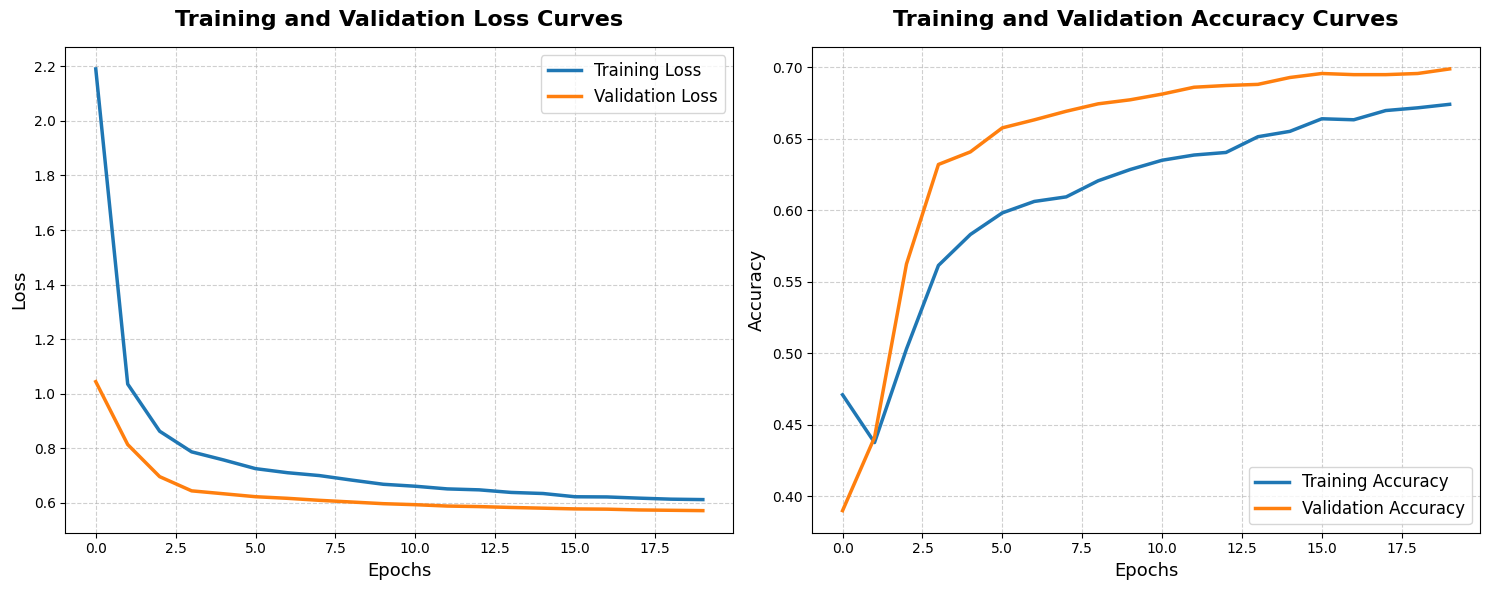

In [14]:
import matplotlib.pyplot as plt

# Plotting Training and Validation Loss & Accuracy in the requested theme
plt.figure(figsize=(15, 6))

# 1. Loss Curves
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss', color='#1f77b4', linewidth=2.5)
plt.plot(history.history['val_loss'], label='Validation Loss', color='#ff7f0e', linewidth=2.5)
plt.title('Training and Validation Loss Curves', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=13)
plt.ylabel('Loss', fontsize=13)
plt.legend(fontsize=12, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

# 2. Accuracy Curves
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='#1f77b4', linewidth=2.5)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='#ff7f0e', linewidth=2.5)
plt.title('Training and Validation Accuracy Curves', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=13)
plt.ylabel('Accuracy', fontsize=13)
plt.legend(fontsize=12, loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [15]:
model.predict(tf.constant(["This is the worst movie I have ever seen",
              "An excellent movie that I enjoyed a lot",
              "how can one make such a horrible movie? there is no story, acting direction everything is very poor"]))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


array([[0.39178962],
       [0.5952291 ],
       [0.5492406 ]], dtype=float32)

In [16]:
model.predict(tf.constant(["An excellent movie that I enjoyed a lot"]))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


array([[0.59522897]], dtype=float32)